In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
from src.dominick import DominickDataLoader

In [3]:
# ============================================
# 1. Imports y configuración
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

NN_PATH = "nn_elasticities_store_upc.csv"
BENCHMARK_PATH = "benchmark_elasticities_store_upc.csv"
KEY_COLS = ["store_code", "upc_code"]
TARGET_COL = "elasticity"

In [4]:
# ============================================
# 2. Carga de datos
# ============================================

loader = DominickDataLoader()
nn = loader.load(NN_PATH)
benchmark = loader.load(BENCHMARK_PATH)

print("NN shape:", nn.shape)
print("Benchmark shape:", benchmark.shape)

print("\nNN columns:")
print(nn.columns.tolist())

print("\nBenchmark columns:")
print(benchmark.columns.tolist())

NN shape: (217, 8)
Benchmark shape: (440, 13)

NN columns:
['store_code', 'upc_code', 'elasticity', 'elasticity_se', 'elasticity_ci_low', 'elasticity_ci_high', 'r2_val', 'n_obs']

Benchmark columns:
['store_code', 'upc_code', 'status', 'n_train', 'n_val', 'elasticity', 'elasticity_se', 'elasticity_ci_low', 'elasticity_ci_high', 'elasticity_p_value', 'mae_val', 'rmse_val', 'r2_val']


In [5]:
# ============================================
# 4. Merge de comparación
# ============================================
df = nn.merge(
    benchmark,
    on=KEY_COLS,
    how="inner",
    suffixes=("_nn", "_benchmark")
)

print("Common pairs:", df.shape[0])

Common pairs: 217


In [6]:
# ============================================
# 5. Métricas de comparación
# ============================================
df["error"] = df["elasticity_nn"] - df["elasticity_benchmark"]
df["abs_error"] = df["error"].abs()
df["sq_error"] = df["error"] ** 2

# Evitamos problemas con signo en 0
df["sign_nn"] = np.sign(df["elasticity_nn"])
df["sign_benchmark"] = np.sign(df["elasticity_benchmark"])
df["same_sign"] = df["sign_nn"] == df["sign_benchmark"]

# Ranking consistency: ¿la NN cae dentro del IC del benchmark?
if {"elasticity_ci_low_benchmark", "elasticity_ci_high_benchmark"}.issubset(df.columns):
    df["nn_in_benchmark_ci"] = (
        (df["elasticity_nn"] >= df["elasticity_ci_low_benchmark"]) &
        (df["elasticity_nn"] <= df["elasticity_ci_high_benchmark"])
    )

if {"elasticity_ci_low_nn", "elasticity_ci_high_nn"}.issubset(df.columns):
    df["benchmark_in_nn_ci"] = (
        (df["elasticity_benchmark"] >= df["elasticity_ci_low_nn"]) &
        (df["elasticity_benchmark"] <= df["elasticity_ci_high_nn"])
    )

summary = {
    "n_common": len(df),
    "mae": df["abs_error"].mean(),
    "rmse": np.sqrt(df["sq_error"].mean()),
    "bias_mean_error": df["error"].mean(),
    "median_abs_error": df["abs_error"].median(),
    "pearson_corr": df["elasticity_nn"].corr(df["elasticity_benchmark"]),
    "sign_accuracy": df["same_sign"].mean(),
}

if "nn_in_benchmark_ci" in df.columns:
    summary["nn_in_benchmark_ci_rate"] = df["nn_in_benchmark_ci"].mean()

if "benchmark_in_nn_ci" in df.columns:
    summary["benchmark_in_nn_ci_rate"] = df["benchmark_in_nn_ci"].mean()

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
summary_df

,value
n_common,217.000000
mae,1.493271
rmse,1.772979
bias_mean_error,0.790136
median_abs_error,1.243819
pearson_corr,0.578985
sign_accuracy,0.986175
nn_in_benchmark_ci_rate,0.516129
benchmark_in_nn_ci_rate,0.087558


In [7]:
# ============================================
# 6. Métricas segmentadas por calidad
# ============================================
# Puedes cambiar los cortes
df["n_obs_bucket"] = pd.cut(
    df["n_obs"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["<=20", "21-50", "51-100", ">100"]
)

df["r2_bucket"] = pd.cut(
    df["r2_val_nn"],
    bins=[-np.inf, 0.1, 0.3, 0.5, np.inf],
    labels=["<=0.1", "0.1-0.3", "0.3-0.5", ">0.5"]
)

def segment_metrics(group):
    return pd.Series({
        "n": len(group),
        "mae": group["abs_error"].mean(),
        "rmse": np.sqrt(group["sq_error"].mean()),
        "bias": group["error"].mean(),
        "corr": group["elasticity_nn"].corr(group["elasticity_benchmark"]) if len(group) > 1 else np.nan,
        "sign_accuracy": group["same_sign"].mean()
    })

metrics_by_nobs = df.groupby("n_obs_bucket", observed=False).apply(segment_metrics).reset_index()
metrics_by_r2 = df.groupby("r2_bucket", observed=False).apply(segment_metrics).reset_index()

print("Metrics by n_obs bucket")
display(metrics_by_nobs)

print("Metrics by r2_val bucket")
display(metrics_by_r2)

Metrics by n_obs bucket


/tmp/ipykernel_52855/3222508591.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_nobs = df.groupby("n_obs_bucket", observed=False).apply(segment_metrics).reset_index()
/tmp/ipykernel_52855/3222508591.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_r2 = df.groupby("r2_bucket", observed=False).apply(segment_metrics).reset_index()


,n_obs_bucket,n,mae,rmse,bias,corr,sign_accuracy
0,<=20,4.0,1.437805,1.869042,-0.233808,0.107073,0.750000
1,21-50,5.0,1.519464,1.771205,1.435871,0.533645,1.000000
2,51-100,208.0,1.493708,1.771124,0.794305,0.583922,0.990385
3,>100,0.0,NaN,NaN,NaN,NaN,NaN


Metrics by r2_val bucket


,r2_bucket,n,mae,rmse,bias,corr,sign_accuracy
0,<=0.1,90.0,1.529997,1.777926,1.086217,0.419276,0.988889
1,0.1-0.3,81.0,1.640975,1.902382,0.494225,0.285626,0.975309
2,0.3-0.5,39.0,1.173341,1.510741,0.680709,0.598327,1.000000
3,>0.5,7.0,1.094396,1.487244,1.017156,-0.290885,1.000000


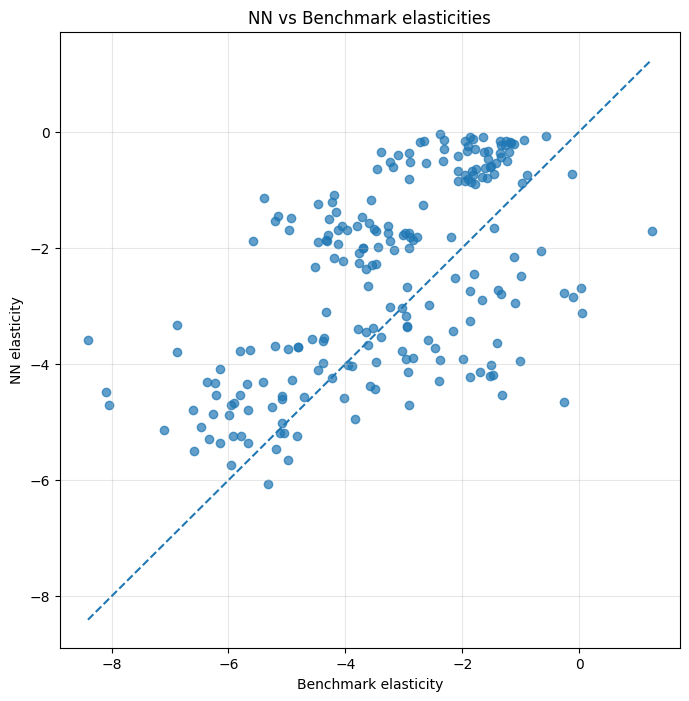

In [8]:
# ============================================
# 7. Scatter plot NN vs Benchmark
# ============================================
plt.figure(figsize=(8, 8))
plt.scatter(df["elasticity_benchmark"], df["elasticity_nn"], alpha=0.7)

min_val = min(df["elasticity_benchmark"].min(), df["elasticity_nn"].min())
max_val = max(df["elasticity_benchmark"].max(), df["elasticity_nn"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Benchmark elasticity")
plt.ylabel("NN elasticity")
plt.title("NN vs Benchmark elasticities")
plt.grid(True, alpha=0.3)
plt.show()

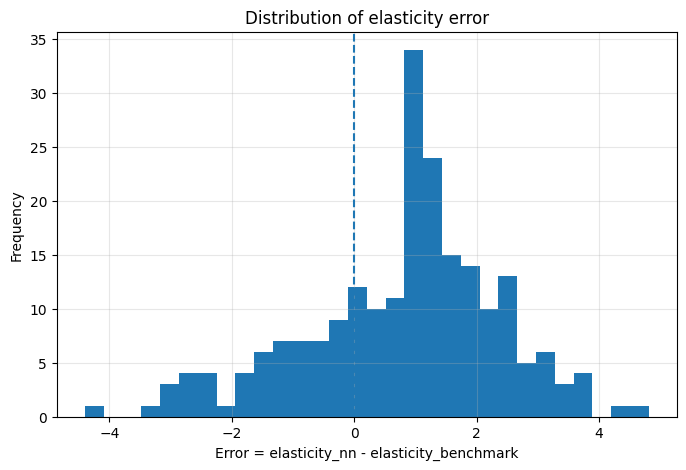

In [9]:
# ============================================
# 8. Distribución del error
# ============================================
plt.figure(figsize=(8, 5))
plt.hist(df["error"], bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Error = elasticity_nn - elasticity_benchmark")
plt.ylabel("Frequency")
plt.title("Distribution of elasticity error")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# ============================================
# 9. Top casos con mayor desviación
# ============================================
cols_to_show = [
    "store_code",
    "upc_code",
    "elasticity_nn",
    "elasticity_benchmark",
    "error",
    "abs_error",
    "n_obs",
    "n_val",
    "r2_val_nn",
    "r2_val_benchmark"
]

top_errors = df.sort_values("abs_error", ascending=False)[cols_to_show].head(10)
top_errors

,store_code,upc_code,elasticity_nn,elasticity_benchmark,error,abs_error,n_obs,n_val,r2_val_nn,r2_val_benchmark
207,133,7289000011,-3.591486,-8.404628,4.813142,4.813142,61.0,61,0.371602,0.032572
118,98,7289000011,-4.652996,-0.258047,-4.394949,4.394949,61.0,61,0.260464,0.295397
98,90,1820000784,-1.141198,-5.398372,4.257174,4.257174,61.0,61,0.093510,-0.162772
16,18,1820000784,-1.876933,-5.578880,3.701947,3.701947,61.0,61,0.096723,0.145598
81,78,1820000784,-1.457044,-5.154148,3.697104,3.697104,61.0,61,0.281564,0.337459
149,110,1820000784,-1.544094,-5.202847,3.658753,3.658753,59.0,59,-0.054146,0.296522
135,103,8248812345,-4.482403,-8.094569,3.612167,3.612167,61.0,61,0.437990,0.474503
163,115,7289000011,-3.328616,-6.873983,3.545367,3.545367,59.0,59,0.198200,-0.638599
37,56,1820000784,-1.477763,-4.926090,3.448327,3.448327,60.0,60,0.146922,-0.089448
69,74,8248812345,-4.713786,-8.044706,3.330920,3.330920,61.0,61,0.504938,0.592709


In [11]:
# ============================================
# 10. Casos donde cambia el signo
# ============================================
sign_flip = df[df["same_sign"] == False].copy()

print("Sign flip cases:", len(sign_flip))
display(
    sign_flip.sort_values("abs_error", ascending=False)[cols_to_show].head(10)
)

Sign flip cases: 3


,store_code,upc_code,elasticity_nn,elasticity_benchmark,error,abs_error,n_obs,n_val,r2_val_nn,r2_val_benchmark
100,90,7289000011,-3.117499,0.047324,-3.164823,3.164823,60.0,60,0.235758,0.066320
0,5,7289000011,-1.708493,1.240572,-2.949064,2.949064,14.0,14,0.219589,0.400615
26,33,7289000011,-2.685712,0.026888,-2.712600,2.712600,61.0,61,-0.299204,0.188924


In [12]:
# ============================================
# 11. Score compuesto para priorizar revisión
# ============================================
# Penaliza error grande y premia evidencia/calidad
# Ajusta la fórmula según vuestro criterio
eps = 1e-8

df["review_score"] = (
    df["abs_error"]
    * (1 + (1 - df["r2_val_nn"].fillna(0)).clip(lower=0))
    * (1 / np.sqrt(df["n_obs"].fillna(1) + eps))
)

review_table = df.sort_values(
    ["same_sign", "abs_error"],
    ascending=[True, False]
)[
    cols_to_show + ["same_sign", "review_score"]
].head(10)

review_table

,store_code,upc_code,elasticity_nn,elasticity_benchmark,error,abs_error,n_obs,n_val,r2_val_nn,r2_val_benchmark,same_sign,review_score
100,90,7289000011,-3.117499,0.047324,-3.164823,3.164823,60.0,60,0.235758,0.066320,False,0.720829
0,5,7289000011,-1.708493,1.240572,-2.949064,2.949064,14.0,14,0.219589,0.400615,False,1.403268
26,33,7289000011,-2.685712,0.026888,-2.712600,2.712600,61.0,61,-0.299204,0.188924,False,0.798543
207,133,7289000011,-3.591486,-8.404628,4.813142,4.813142,61.0,61,0.371602,0.032572,True,1.003516
118,98,7289000011,-4.652996,-0.258047,-4.394949,4.394949,61.0,61,0.260464,0.295397,True,0.978864
98,90,1820000784,-1.141198,-5.398372,4.257174,4.257174,61.0,61,0.093510,-0.162772,True,1.039181
16,18,1820000784,-1.876933,-5.578880,3.701947,3.701947,61.0,61,0.096723,0.145598,True,0.902126
81,78,1820000784,-1.457044,-5.154148,3.697104,3.697104,61.0,61,0.281564,0.337459,True,0.813449
149,110,1820000784,-1.544094,-5.202847,3.658753,3.658753,59.0,59,-0.054146,0.296522,True,0.978449
135,103,8248812345,-4.482403,-8.094569,3.612167,3.612167,61.0,61,0.437990,0.474503,True,0.722415


In [13]:
# ============================================
# 12. Comparación con tolerancias de negocio
# ============================================
# Define reglas de aceptación
ABS_ERROR_THRESHOLD = 0.5
CORRECT_SIGN_REQUIRED = True

df["pass_abs_error"] = df["abs_error"] <= ABS_ERROR_THRESHOLD
df["pass_sign"] = df["same_sign"] if CORRECT_SIGN_REQUIRED else True
df["pass_overall"] = df["pass_abs_error"] & df["pass_sign"]

acceptance_summary = pd.DataFrame({
    "metric": [
        "acceptance_rate",
        "abs_error_pass_rate",
        "sign_pass_rate"
    ],
    "value": [
        df["pass_overall"].mean(),
        df["pass_abs_error"].mean(),
        df["pass_sign"].mean()
    ]
})

acceptance_summary

,metric,value
0,acceptance_rate,0.152074
1,abs_error_pass_rate,0.152074
2,sign_pass_rate,0.986175
